In [9]:
import geopandas as gpd
import pandas as pd

geom = gpd.read_file('src/Vectorisation/')
geom = geom.reset_index()
geom.rename(columns={'index': 'geom_id'}, inplace=True)
df = pd.read_excel('src/legende_renove_2.xlsx')
# only one entry with no folio, we can drop it (only information is in column "*": 'MANQUE DES NUMEROS POUR FO. 10 (IL MANQUE PROBABLEMENT UNE PAGE)')
df = df[df['folio'].notnull()]
points = gpd.read_file('src/numeros_merged-v2.json') # no null values in the relevant part. 
print(len(points))
points.drop(columns=['id'], inplace=True)
points = points.drop_duplicates()
print(len(points))

def check_decimal_vals(df, col) -> None:
    tdf = df.copy()
    tdf['decimal_part'] = tdf.apply(lambda x: x[col] - int(x[col]), axis=1)
    dec_vals = list(tdf.decimal_part.value_counts().items())
    if len(dec_vals) > 1 or (len(dec_vals) == 1 and dec_vals[0][0] != 0.0):
        print(f'There are {col} with decimal parts. This is unexpected.')
        print(dec_vals)
        print('Please check the data.')

def number_to_parcel_id(number: float) -> str:
    str_number = str(number)
    if '.' not in str_number:
        return str_number
    vals = [v.strip() for v in str(number).split('.')]
    if len(vals) == 1:
        print(f'Unexpected value: {number}.')
        return vals[0]
    main_part = vals[0]
    decim_part = vals[1]
    if decim_part == '0':
        return main_part
    return f'{main_part}-{decim_part}'

def fix_numerical_error(v:float) -> str:
    return str(float(int(10*float(v)))/(10.))

check_decimal_vals(df, 'folio')
check_decimal_vals(points, 'folio')
df['parcel_id'] = df['nr'].apply(number_to_parcel_id)
df['folio'] = df['folio'].astype(int).astype(str)
points['folio'] = points['folio'].astype(int).astype(str)
points['num'] = points['num'].apply(fix_numerical_error) # fix numerical error
points['parcel_id'] = points['num'].apply(number_to_parcel_id)
df['merge_id'] = df['folio'] + 'f' + df['parcel_id']
points['merge_id'] = points['folio'] + 'f' + points['parcel_id']


13887
13887


In [10]:
from shapely.geometry import Point, Polygon
from tqdm.notebook import tqdm

def locate_parcel_geom_id(geom: list[tuple[str, Polygon]], point: Point) -> str:
    for id, geometry in geom:
        if geometry.contains(point):
            return id
    return None

geom_dict = list(geom.set_index('geom_id')['geometry'].to_dict().items())
geom_dict

# this part is slow, around 25 to 30 minutes. Optimisation possible according to that link, but require numba: https://stackoverflow.com/questions/36399381/whats-the-fastest-way-of-checking-if-a-point-is-inside-a-polygon-in-python
points['geom_id'] = [locate_parcel_geom_id(geom_dict, row.geometry) for row in tqdm(points.itertuples(), total=len(points), desc="Locating parcel geom_id")]
points['geom_id'] = points['geom_id'].apply(lambda x: str(int(x)) if not pd.isna(x) else None)

Locating parcel geom_id:   0%|          | 0/13887 [00:00<?, ?it/s]

In [11]:
# so we don't need to recompute the geometry and to which polygon they belong. 
points.to_crs('EPSG:4326').to_file('src/numeros_merged-v3.geojson', driver='GeoJSON')
geom.to_crs('EPSG:4326').to_file('src/geometries_with_index.geojson', driver='GeoJSON')

In [13]:
num_df = gpd.read_file('src/numeros_merged-v3.geojson')
num_df.drop(columns=['id'], inplace=True, errors='ignore')
num_df = num_df.drop_duplicates()
gdf = gpd.read_file('src/geometries_with_index.geojson')

In [14]:
num_df.columns, gdf.columns, df.columns

(Index(['num', 'folio', 'parcel_id', 'merge_id', 'geom_id', 'geometry'], dtype='str'),
 Index(['geom_id', 'class', 'layer', 'geometry'], dtype='str'),
 Index(['*', 'folio', 'nr', 'articles', 'Noms locaux', 'ares', 'cent',
        'prix proportionnels par are de la commission cadastrale', 'use',
        'owner', 'parcel_id', 'merge_id'],
       dtype='str'))

In [15]:
# Merge df (legend) with num_df (numbers with geom_id) on merge_id
merged_df = df.merge(num_df[['merge_id', 'geom_id', 'geometry']], on='merge_id', how='left')

# Ensure geom_id is consistent type (string) before merging
merged_df['geom_id'] = merged_df['geom_id'].astype(str)
gdf['geom_id'] = gdf['geom_id'].astype(str)

# Merge with gdf (geometries) on geom_id to get parcel geometries
merged_df = merged_df.merge(gdf[['geom_id', 'geometry']], on='geom_id', how='left', suffixes=('_point', '_parcel'))

# Group by the primary key (assuming "*" column is the parcel identifier) to handle multiple numbers per parcel
# Aggregate geometries and numbers if one parcel has multiple entries
df_final = merged_df.groupby('*').agg({
    'use': 'first',  # use should be same for all entries of same parcel
    'folio': 'first',
    'nr': lambda x: list(x.dropna()),  # collect all parcel numbers
    'geometry_parcel': 'first',  # parcel geometry (should be same)
    'geometry_point': lambda x: list(x.dropna()),  # collect all point geometries
}).reset_index()

# Keep only the parcel geometry as the main geometry
df_final = df_final.rename(columns={'geometry_parcel': 'geometry'})
df_final = df_final.drop(columns=['geometry_point'], errors='ignore')

print(f"Created df_final with {len(df_final)} rows")
print(f"Columns: {df_final.columns.tolist()}")
df_final.head()

Created df_final with 13515 rows
Columns: ['*', 'use', 'folio', 'nr', 'geometry']


,*,use,folio,nr,geometry
0,1,Magasin sur domaine public,1,[1.0],"POLYGON ((6.63308 46.52293, 6.63305 46.52294, ..."
1,2,Magasin sur domaine public,1,[2.0],"POLYGON ((6.63305 46.52292, 6.63308 46.52292, ..."
2,3,Magasin sur domaine public,1,[3.0],"POLYGON ((6.63305 46.52286, 6.63307 46.52286, ..."
3,4,Place,1,[4.0],"POLYGON ((6.63309 46.523, 6.63319 46.52302, 6...."
4,5,Couvert de fontaine,1,[5.0],"POLYGON ((6.63359 46.52284, 6.63365 46.52283, ..."


In [16]:
from collections import Counter
import re
import unicodedata
import json


def normalize_text(value: str) -> str:
    if pd.isna(value):
        return ""
    txt = str(value).strip().lower()
    txt = "".join(
        c for c in unicodedata.normalize("NFD", txt)
        if unicodedata.category(c) != "Mn"
    )
    txt = re.sub(r"[^a-z0-9\s]", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt


# Regex patterns → target English categories
# volière is intentionally excluded (deleted)
TARGET_PATTERNS = [
    ("allotments",      [r"\bjardin\b", r"\bcheneviere\b", r"\bverger\b", r"\bpotager\b"]),
    ("animal_keeping",  [r"\becurie\b", r"\becuries\b",
                         r"\betable\b", r"\betables\b",
                         r"\bgrange\b", r"\bgranges\b", r"\bgrance\b",
                         r"\bfenil\b",  r"\bfenils\b",
                         r"\bhangar\b",
                         r"\bfumier\b",
                         r"\bbasse.?cour\b",
                         r"\babattoir\b"]),
    ("basin",           [r"\breservoir\b", r"\bbaignoire\b", r"\bbains\b", r"\bbassin\b"]),
    ("farmland",        [r"\bchamp\b", r"\bchamps\b", r"\bterre\b", r"\bgrenier\b"]),
    ("forest",          [r"\bbois\b", r"\bforet\b", r"\bbosquet\b", r"\bbuissons?\b"]),
    ("grass",           [r"\bpre\b", r"\bpres\b", r"\bpaturage\b", r"\bprairie\b"]),
    ("greenhouse_horti",[r"\bserre\b"]),
    ("plant_nursery",   [r"\bpepiniere\b", r"\bplantage\b"]),
    ("vineyard",        [r"\bvigne\b", r"\bvignes\b", r"\bpressoir\b"]),
]

VOLIERE_RE = re.compile(r"\bvoliere\b")


def map_item_to_category(use_item: str):
    """Return the English category for a single use term, or None (not agricultural / volière)."""
    norm = normalize_text(use_item)
    if VOLIERE_RE.search(norm):
        return None  # deleted per request
    for category, patterns in TARGET_PATTERNS:
        if any(re.search(p, norm) for p in patterns):
            return category
    return None


def split_use_string(use_val):
    if pd.isna(use_val):
        return []
    if isinstance(use_val, list):
        return use_val
    return [item.strip() for item in str(use_val).split(",") if item.strip()]


def harmonize_uses(use_val):
    cats = {map_item_to_category(item) for item in split_use_string(use_val)}
    cats.discard(None)
    return sorted(cats) if cats else None


# ── Build harmonized GeoDataFrame from the already-merged df_final ─────────────
gdf_agri = gpd.GeoDataFrame(df_final.copy(), geometry="geometry", crs="EPSG:4326")
gdf_agri["use_harmonized"] = gdf_agri["use"].apply(harmonize_uses)

# Keep only parcels matching at least one target category
gdf_agri = gdf_agri[gdf_agri["use_harmonized"].notna()].copy()

# use_fr = original French string; use = harmonized English list (kept as list in memory)
gdf_agri = gdf_agri.rename(columns={"use": "use_fr", "use_harmonized": "use"})

print(f"Agricultural/forest features: {len(gdf_agri)}")
cat_counts = Counter(c for cats in gdf_agri["use"] for c in cats)
for cat, count in sorted(cat_counts.items()):
    print(f"  {cat}: {count}")

# Serialize list columns as JSON strings so fiona preserves them in GeoJSON
gdf_save = gdf_agri.copy()
gdf_save["use"] = gdf_save["use"].apply(json.dumps)
gdf_save["nr"]  = gdf_save["nr"].apply(lambda x: json.dumps(x) if isinstance(x, list) else x)
gdf_save.to_file("lausanne-1888-agriculture-harmonized.geojson", driver="GeoJSON")
print("Saved → lausanne-1888-agriculture-harmonized.geojson")


Agricultural/forest features: 6303
  allotments: 1286
  animal_keeping: 1160
  basin: 26
  farmland: 975
  forest: 708
  grass: 1299
  greenhouse_horti: 122
  plant_nursery: 1
  vineyard: 743
Saved → lausanne-1888-agriculture-harmonized.geojson


                  n_parcels  total_area_ha
category                                  
allotments             1189     104.614530
animal_keeping         1087      66.649156
basin                    22       0.969845
farmland                872     774.844532
forest                  669     704.971886
grass                  1169     857.148655
greenhouse_horti        113       1.106396
plant_nursery             0       0.000000
vineyard                712     168.546418


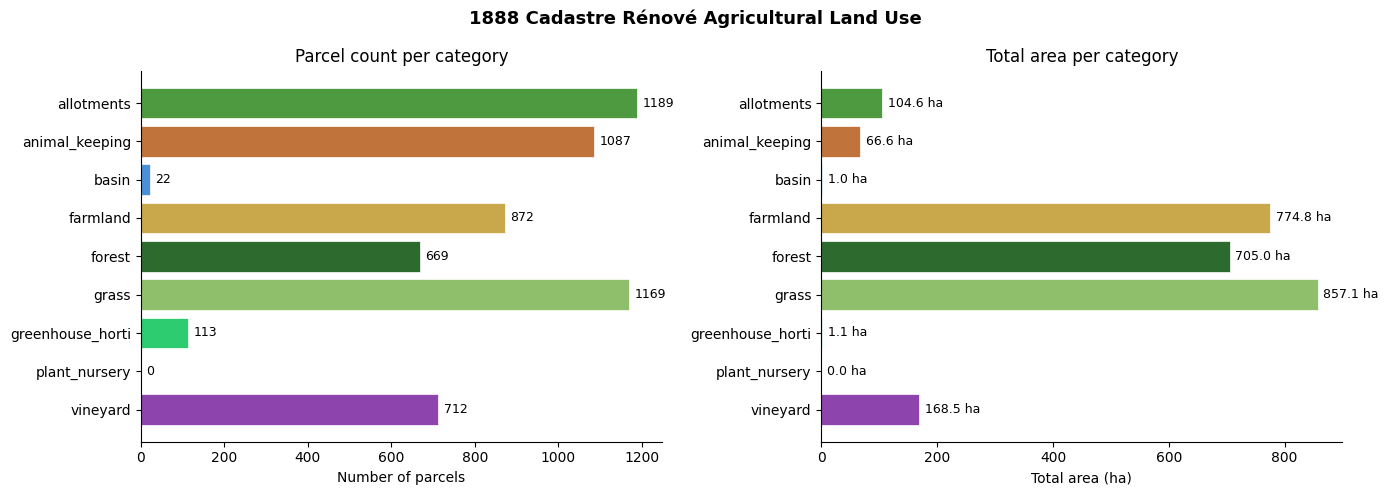

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

PALETTE = {
    "allotments":       "#4e9a41",
    "animal_keeping":   "#c0743c",
    "basin":            "#4a90d9",
    "farmland":         "#c8a84b",
    "forest":           "#2d6a2d",
    "grass":            "#8fbf6a",
    "greenhouse_horti": "#2ecc71",
    "plant_nursery":    "#1abc9c",
    "vineyard":         "#8e44ad",
}

# Project to metric CRS for area calculation
gdf_agri["area_ares"] = gdf_agri.to_crs("EPSG:2056").geometry.area / 100

# Explode harmonized categories for per-category statistics
exp = (
    pd.DataFrame(gdf_agri[["use", "area_ares"]])
    .explode("use")
    .rename(columns={"use": "category"})
)
exp = exp[exp["category"].notna() & (exp["category"] != "")]

stats = (
    exp.groupby("category")
    .agg(
        n_parcels    =("area_ares", "count"),
        total_area_ha=("area_ares", lambda x: x.sum() / 100),
    )
)

print(stats.to_string())

# Bar charts: parcel count and total area per category
colors = [PALETTE.get(c, "#aaaaaa") for c in stats.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1888 Cadastre Rénové Agricultural Land Use", fontsize=13, fontweight="bold")

ax = axes[0]
bars = ax.barh(stats.index, stats["n_parcels"], color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("Number of parcels")
ax.set_title("Parcel count per category")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
bars = ax.barh(stats.index, stats["total_area_ha"], color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, fmt="%.1f ha", padding=4, fontsize=9)
ax.set_xlabel("Total area (ha)")
ax.set_title("Total area per category")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("1888_agri_count_and_area.png", dpi=150, bbox_inches="tight")
plt.show()


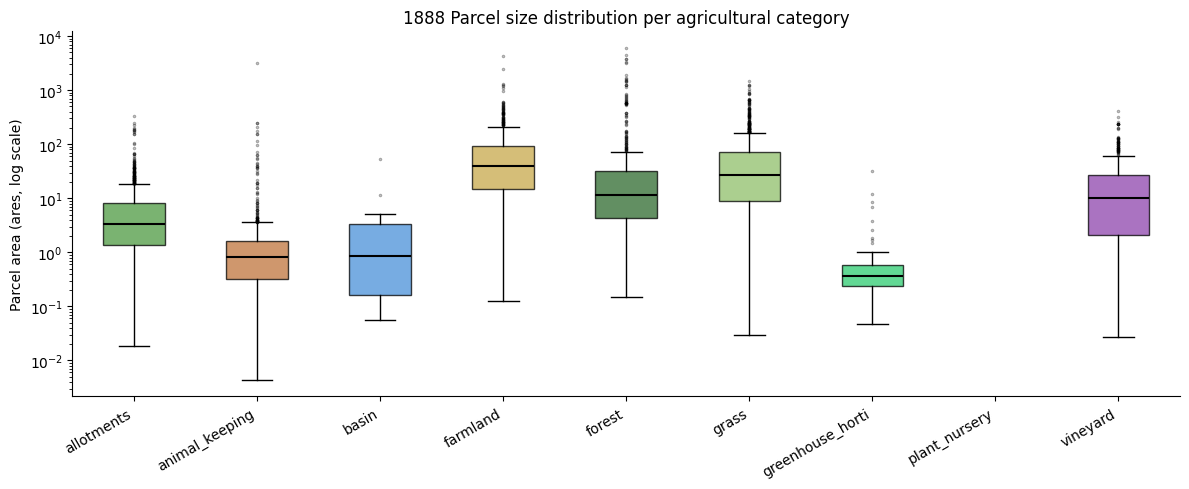

Single-category parcels:  6286  (99.7%)
Multi-category parcels :    17  (0.3%)
Top co-occurring category pairs:
  animal_keeping + vineyard: 14
  allotments + plant_nursery: 1
  basin + grass: 1
  farmland + vineyard: 1


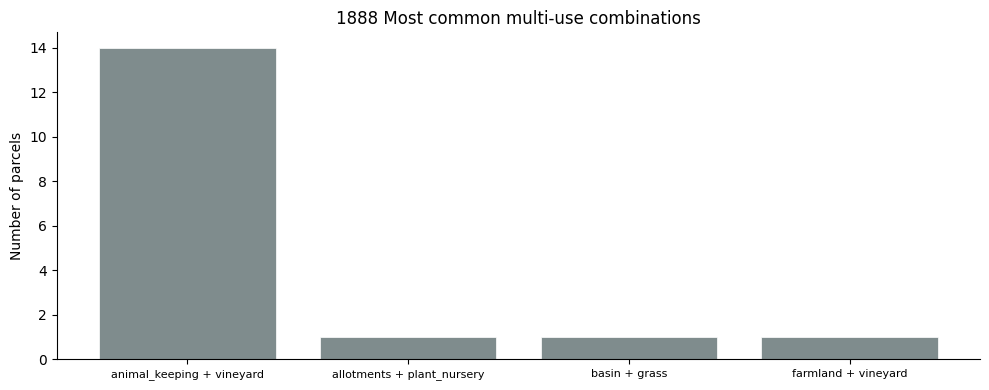

In [21]:
# Box plot: parcel size distribution per category
# Filter out zero-area rows (parcels with unmatched/null polygon geometry)
exp_valid = exp[exp["area_ares"] > 0]
cat_order = stats.index.tolist()
data_by_cat = [exp_valid[exp_valid["category"] == cat]["area_ares"].values for cat in cat_order]
colors_ordered = [PALETTE.get(c, "#aaaaaa") for c in cat_order]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(
    data_by_cat,
    vert=True,
    patch_artist=True,
    tick_labels=cat_order,
    showfliers=True,
    flierprops=dict(marker=".", markersize=3, alpha=0.35, color="grey"),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)
for patch, color in zip(bp["boxes"], colors_ordered):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_yscale("log")
ax.set_ylabel("Parcel area (ares, log scale)")
ax.set_title("1888 Parcel size distribution per agricultural category")
plt.xticks(rotation=30, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("1888_agri_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Multi-use parcels and co-occurrence
from itertools import combinations

multi = gdf_agri[gdf_agri["use"].apply(len) > 1]
print(f"Single-category parcels: {len(gdf_agri) - len(multi):>5}  ({100*(1-len(multi)/len(gdf_agri)):.1f}%)")
print(f"Multi-category parcels : {len(multi):>5}  ({100*len(multi)/len(gdf_agri):.1f}%)")

pair_counts = Counter()
for cats in multi["use"]:
    for pair in combinations(sorted(cats), 2):
        pair_counts[pair] += 1

print("Top co-occurring category pairs:")
top_pairs = pair_counts.most_common(10)
for (a, b), n in top_pairs:
    print(f"  {a} + {b}: {n}")

if top_pairs:
    labels = [f"{a} + {b}" for (a, b), _ in top_pairs]
    counts = [n for _, n in top_pairs]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(labels, counts, color="#7f8c8d", edgecolor="white", linewidth=0.5)
    ax.set_ylabel("Number of parcels")
    ax.set_title("1888 Most common multi-use combinations")
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(fontsize=8)
    plt.tight_layout()
    plt.savefig("1888_agri_cooccurrence.png", dpi=150, bbox_inches="tight")
    plt.show()
